# E2: Anomaly Detection — Do NLEs Help or Hurt?

**Research question:** When model inputs are pushed to out-of-distribution (OOD) values, does an NLE help or hurt the judge's ability to detect the anomaly?

## Design

2×2 factorial: **Poisoning level** (baseline / OOD) × **NLE** (with / without).
All conditions include features + SHAP + metrics (matching E1's X+T baseline).

| Condition | Poisoning | Features | SHAP (X) | Metrics (T) | NLE (E) |
|-----------|-----------|:--:|:--:|:--:|:--:|
| baseline_no_nle | None | ✓ | ✓ | ✓ | ✗ |
| baseline_nle | None | ✓ | ✓ | ✓ | ✓ |
| ood_no_nle | OOD | ✓ | ✓ | ✓ | ✗ |
| ood_nle | OOD | ✓ | ✓ | ✓ | ✓ |

**Poisoning method (same as Paper 1 E2):**
- Only lag features (lag_1–lag_7) are modified; weekofyear and holiday_week_count stay unchanged
- Direction depends on season: cold season (weeks 44–17) → push lags LOW (abnormally low in winter); warm season (weeks 18–43) → push lags HIGH (abnormally high in summer)
- OOD level: cold → 0.8 × min(all lags), warm → 1.2 × max(all lags)
- Decay factor per lag: lag_i gets factor 1.0 − (i−1)×0.05 (lag_1 = full, lag_7 = 0.7×)
- Noise: uniform [−5, +5] kWh per lag
- After poisoning: re-compute XGBoost prediction and SHAP values from scratch
- NLEs for poisoned instances are generated separately (they rationalize the OOD features)

**2×2 generator×judge design:** NLE conditions use both GPT-4o and DeepSeek-R1 as generators and judges (4 combinations). No-NLE conditions have no generator dimension — just 2 judges.

**Training data distribution stats** are always included (judge needs a reference for "normal").

## Judge task

Binary reliability decision + confidence:
- **Reliability**: reliable or unreliable — **primary outcome**
- **Confidence (1–5)**: How certain are you? (1 = very uncertain, 5 = very certain)

**Ground truth:**
- Baseline instances → **reliable** (normal features, model trained on similar data)
- OOD instances → **unreliable** (poisoned features far from training distribution)

The hypothesis: OOD features should produce unreliable predictions (the model hasn't seen such inputs). NLEs may rationalize the anomalous features, reducing the judge's suspicion ("false reassurance").

## Judgment count

Per poisoning level:
- No NLE: N × 2 judges
- With NLE: N × 2 generators × 2 judges

- **Pilot (N=15):** 2 × (15×2 + 15×4) = 2 × 90 = **180**
- **Full (N=60):** 2 × (60×2 + 60×4) = 2 × 360 = **720**

## Key analyses

1. **Overall accuracy:** % correct reliability classifications across all conditions
2. **Manipulation check:** baseline vs OOD accuracy (OOD should be detectable)
3. **Primary:** OOD accuracy with NLE vs without NLE — does NLE reduce detection?
4. **False reassurance rate:** % of OOD instances incorrectly classified as reliable (false negatives)
5. **Interaction:** Poisoning × NLE on accuracy

## Statistical plan

- **Primary:** GLMM logistic: `correct ~ poisoning * nle + judge + (1|instance)`
- **Key contrast:** OOD detection accuracy: NLE vs no-NLE (McNemar's test or paired proportion)
- **Effect sizes:** Cohen's h on accuracy differences
- **Pilot (N=15) → effect size → power check → Full (N=60)**

## 0. Setup

In [1]:
import os
import sys
import asyncio
import json
import re
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt

import utils

# ── Toggle: pilot vs full ──────────────────────────────────────────
PILOT_MODE = False   # Set False for full experiment
N = 15 if PILOT_MODE else 60
RANDOM_SEED = 42
# ───────────────────────────────────────────────────────────────────

# Override from run_all.py script
if os.environ.get('EXPERIMENT_N'):
    N = int(os.environ['EXPERIMENT_N'])
    PILOT_MODE = N < 60

RESULTS_DIR = utils.RESULTS_DIR / 'E2'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 2×2 factorial: poisoning level × NLE
POISONING_LEVELS = ['baseline', 'ood']
NLE_CONDITIONS = [False, True]

mode_str = f'PILOT (N={N})' if PILOT_MODE else f'FULL (N={N})'
print(f'E2 Anomaly Detection — {mode_str}')
print(f'Poisoning levels: {POISONING_LEVELS}')
print(f'NLE conditions: {NLE_CONDITIONS}')

E2 Anomaly Detection — FULL (N=60)
Poisoning levels: ['baseline', 'ood']
NLE conditions: [False, True]


## 1. Load data

In [2]:
# Load test instances with SHAP values
model = utils.load_xgb_model()
test_df = utils.build_test_with_shap(model)

# Load NLE cache for baseline instances (from shared Step 0)
nle_cache = utils.load_nle_cache()

# NLE lookup for baseline: {(RowPos, generator) -> Explanation}
nle_lookup_baseline = {}
for _, nle_row in nle_cache.iterrows():
    nle_lookup_baseline[(int(nle_row['RowPos']), nle_row['generator'])] = nle_row['Explanation']

# Combined lag distribution (for poisoning targets)
LAG_FEATURES = [f'lag_{i}' for i in range(1, 8)]
all_lag_vals = test_df[LAG_FEATURES].values.flatten()
LAG_STATS = {
    'min': float(all_lag_vals.min()),
    'max': float(all_lag_vals.max()),
    'mean': float(all_lag_vals.mean()),
    'std': float(all_lag_vals.std()),
    'p5': float(np.percentile(all_lag_vals, 5)),
    'p25': float(np.percentile(all_lag_vals, 25)),
    'p75': float(np.percentile(all_lag_vals, 75)),
    'p95': float(np.percentile(all_lag_vals, 95)),
}

print(f'Test instances: {len(test_df)}')
print(f'NLE cache: {len(nle_cache)} rows')
print(f'Lag distribution: mean={LAG_STATS["mean"]:.1f}, std={LAG_STATS["std"]:.1f}, '
      f'range=[{LAG_STATS["min"]:.1f}, {LAG_STATS["max"]:.1f}]')

# Season assignment
test_df['season'] = test_df['weekofyear'].apply(
    lambda w: 'cold' if (w >= 44 or w <= 17) else 'warm'
)

# Sample N instances (stratified by season for balanced poisoning directions)
if N < len(test_df):
    sampled_indices = []
    for season, group in test_df.groupby('season'):
        n_from = max(1, round(N * len(group) / len(test_df)))
        sampled_indices.extend(group.sample(min(len(group), n_from),
                                            random_state=RANDOM_SEED).index.tolist())
    if len(sampled_indices) < N:
        remaining = [i for i in test_df.index if i not in sampled_indices]
        extra = np.random.default_rng(RANDOM_SEED).choice(remaining, N - len(sampled_indices), replace=False)
        sampled_indices.extend(extra.tolist())
    sampled_indices = sampled_indices[:N]
    sample_df = test_df.loc[sampled_indices].copy()
else:
    sample_df = test_df.copy()

sample_df['orig_idx'] = sample_df.index
sample_df = sample_df.reset_index(drop=True)

print(f'\nUsing {len(sample_df)} instances')
print('Season distribution:', sample_df['season'].value_counts().to_dict())
print('orig_idx values:', sorted(sample_df['orig_idx'].tolist()))

Test instances: 60
NLE cache: 120 rows
Lag distribution: mean=183.8, std=43.7, range=[63.5, 273.3]

Using 60 instances
Season distribution: {'cold': 32, 'warm': 28}
orig_idx values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]


## 2. Poison instances

For each instance, create an OOD version by pushing lag features to extreme values.
Re-compute XGBoost prediction and SHAP values for each poisoned instance.

In [3]:
rng = np.random.default_rng(RANDOM_SEED)

def poison_instance(row: pd.Series, level: str = 'ood') -> pd.Series:
    """Create a poisoned version of an instance (OOD level).
    
    Cold season (weeks 44-17): push lags LOW (abnormally low in winter)
    Warm season (weeks 18-43): push lags HIGH (abnormally high in summer)
    """
    poisoned = row.copy()
    season = row['season']
    
    if level == 'baseline':
        return poisoned
    
    # OOD targets
    if season == 'cold':
        target = 0.8 * LAG_STATS['min']  # ~50.8 kWh — abnormally low for winter
    else:
        target = 1.2 * LAG_STATS['max']  # ~327.9 kWh — abnormally high for summer
    
    for i, lag in enumerate(LAG_FEATURES):
        decay = 1.0 - i * 0.05  # lag_1=1.0, lag_7=0.7
        noise = rng.uniform(-5, 5)
        poisoned[lag] = target * decay + noise
    
    return poisoned


# Create poisoned instances and re-compute predictions + SHAP
poisoned_rows = []
for _, row in sample_df.iterrows():
    p_row = poison_instance(row, 'ood')
    poisoned_rows.append(p_row)

poisoned_df = pd.DataFrame(poisoned_rows)

# Re-compute predictions on poisoned features
X_poisoned = poisoned_df[utils.FEATURES].values
poisoned_df['prediction_ood'] = model.predict(X_poisoned)

# Re-compute SHAP values on poisoned features
import shap
explainer = shap.TreeExplainer(model)
shap_poisoned = explainer.shap_values(X_poisoned)
if isinstance(shap_poisoned, list):
    shap_poisoned = shap_poisoned[0]
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = float(base_value[0])

for i, feat in enumerate(utils.FEATURES):
    poisoned_df[f'shap_ood_{feat}'] = shap_poisoned[:, i]
poisoned_df['shap_ood_base_value'] = base_value

# Merge back with sample_df
sample_df['prediction_ood'] = poisoned_df['prediction_ood'].values
sample_df['shap_ood_base_value'] = poisoned_df['shap_ood_base_value'].values
for feat in utils.FEATURES:
    sample_df[f'ood_{feat}'] = poisoned_df[feat].values
    sample_df[f'shap_ood_{feat}'] = poisoned_df[f'shap_ood_{feat}'].values

# Preview
print('=== Poisoning preview (first instance) ===')
r = sample_df.iloc[0]
print(f'Season: {r["season"]}, weekofyear: {r["weekofyear"]}')
print(f'Original lag_1: {r["lag_1"]:.1f} → Poisoned lag_1: {r["ood_lag_1"]:.1f}')
print(f'Original lag_7: {r["lag_7"]:.1f} → Poisoned lag_7: {r["ood_lag_7"]:.1f}')
print(f'Original prediction: {r["prediction"]:.2f} → Poisoned prediction: {r["prediction_ood"]:.2f}')
print()
print('=== Poisoned lag statistics ===')
for lag in LAG_FEATURES:
    orig = sample_df[lag].values
    pois = sample_df[f'ood_{lag}'].values
    print(f'  {lag}: orig mean={orig.mean():.1f}, poisoned mean={pois.mean():.1f}')

=== Poisoning preview (first instance) ===
Season: warm, weekofyear: 42
Original lag_1: 166.3 → Poisoned lag_1: 330.7
Original lag_7: 129.4 → Poisoned lag_7: 232.2
Original prediction: 168.76 → Poisoned prediction: 232.54

=== Poisoned lag statistics ===
  lag_1: orig mean=185.6, poisoned mean=179.5
  lag_2: orig mean=185.2, poisoned mean=171.1
  lag_3: orig mean=184.6, poisoned mean=161.8
  lag_4: orig mean=184.1, poisoned mean=153.6
  lag_5: orig mean=183.7, poisoned mean=144.2
  lag_6: orig mean=182.5, poisoned mean=135.6
  lag_7: orig mean=181.3, poisoned mean=125.8


## 3. Generate NLEs for poisoned instances

Baseline instances use the shared NLE cache from Step 0.
Poisoned instances need NEW NLEs that describe the OOD features — the NLE will attempt to rationalize the anomalous values, which is exactly what we want to test.

In [4]:
NLE_CACHE_PATH = RESULTS_DIR / 'nle_cache_poisoned.csv'

# Build a "fake row" for each poisoned instance that format_nle_prompt can consume
def make_poisoned_nle_row(row: pd.Series) -> pd.Series:
    """Build a row with poisoned features/prediction/SHAP for NLE generation."""
    nle_row = pd.Series(dtype=object)
    for feat in utils.FEATURES:
        nle_row[feat] = row[f'ood_{feat}']
    nle_row['prediction'] = row['prediction_ood']
    nle_row['shap_base_value'] = row['shap_ood_base_value']
    for feat in utils.FEATURES:
        nle_row[f'shap_{feat}'] = row[f'shap_ood_{feat}']
    return nle_row


# Resume support
if NLE_CACHE_PATH.exists():
    existing_nles = pd.read_csv(NLE_CACHE_PATH)
    done_nle_keys = set(zip(existing_nles['orig_idx'].astype(int),
                            existing_nles['generator']))
    nle_results = existing_nles.to_dict('records')
    print(f'NLE cache: {len(nle_results)} existing entries loaded.')
else:
    done_nle_keys = set()
    nle_results = []


async def generate_one_nle(orig_idx: int, row: pd.Series, generator: str) -> dict:
    """Generate NLE for a poisoned instance."""
    nle_row = make_poisoned_nle_row(row)
    system_msg, human_msg = utils.format_nle_prompt(nle_row)
    
    if generator == 'gpt':
        success, result, retries, latency, err = await utils.async_call_gpt(
            system_msg, human_msg, temperature=0.0, max_tokens=500
        )
    else:
        success, result, retries, latency, err = await utils.async_call_deepseek(
            system_msg, human_msg, temperature=0.0, max_tokens=800
        )
    
    text = (result or {}).get('text', '') if success else f'ERROR: {err}'
    
    return {
        'orig_idx': orig_idx,
        'generator': generator,
        'nle': text,
        'system_msg': system_msg,
        'human_msg': human_msg,
        'Duration_s': round(latency, 2) if success else None,
        'success': success,
        'error': err,
    }


# Build NLE generation tasks
nle_tasks = []
for _, row in sample_df.iterrows():
    orig_idx = int(row['orig_idx'])
    for gen in ['gpt', 'deepseek']:
        if (orig_idx, gen) not in done_nle_keys:
            nle_tasks.append(generate_one_nle(orig_idx, row, gen))

print(f'NLE tasks to run: {len(nle_tasks)}')
print(f'Already done: {len(done_nle_keys)}')

if nle_tasks:
    new_nles = await utils.run_async_tasks(nle_tasks, desc=f'E2 NLE generation ({len(nle_tasks)} calls)')
    nle_results.extend(new_nles)
    pd.DataFrame(nle_results).to_csv(NLE_CACHE_PATH, index=False)
    print(f'Saved {len(nle_results)} NLEs → {NLE_CACHE_PATH}')
else:
    print('All poisoned NLEs already cached.')

# Build NLE lookup for poisoned instances
nle_lookup_poisoned = {}
for r in nle_results:
    if r.get('success', True) and not str(r.get('nle', '')).startswith('ERROR'):
        nle_lookup_poisoned[(int(r['orig_idx']), r['generator'])] = r['nle']

print(f'\nPoisoned NLE lookup: {len(nle_lookup_poisoned)} entries')
# Preview
if nle_lookup_poisoned:
    k = next(iter(nle_lookup_poisoned))
    print(f'Preview ({k[1]} NLE for instance {k[0]}, first 200 chars):')
    print(nle_lookup_poisoned[k][:200])

NLE cache: 30 existing entries loaded.
NLE tasks to run: 90
Already done: 30


E2 NLE generation (90 calls):   0%|          | 0/90 [00:00<?, ?it/s]

Saved 120 NLEs → /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E2/nle_cache_poisoned.csv

Poisoned NLE lookup: 115 entries
Preview (gpt NLE for instance 57, first 200 chars):
- The model predicts energy consumption for the next week based on past weekly data and other factors like the week of the year and holidays.
- The prediction of 148.79 kWh is influenced by recent ene


## 4. Build judge prompts

In [5]:
JUDGE_SYSTEM = """You are evaluating a machine learning model's prediction for a time series forecasting task.
You have limited background in machine learning and statistics — you understand basic concepts but are not an expert.

Your task: Based on all the information provided, decide whether this prediction is reliable or unreliable. Consider whether the input features look normal or unusual, whether they match expected patterns for the time of year, and whether the model can be trusted given these inputs.

Evaluation steps (think through each before giving your final answer):
1. Examine the features — consider the lag values, the time of year (season in France), holidays, and whether the prediction seems reasonable given this context
2. If SHAP values are provided, consider whether each feature's contribution makes sense given the feature values and context
3. Consider the model performance metrics to gauge general trustworthiness
4. If a natural language explanation is provided, you can use it to better understand the model's reasoning
5. Weigh all evidence to decide whether this prediction can be trusted

Reliability:
- reliable = The prediction can be trusted — inputs look normal and within what the model was trained on
- unreliable = The prediction should not be trusted — inputs look unusual or far from what the model was trained on

Confidence scale:
- 1 = Very uncertain about my assessment
- 2 = Somewhat uncertain
- 3 = Moderately confident
- 4 = Fairly confident
- 5 = Very certain about my assessment

You must respond with EXACTLY this JSON format and nothing else:
{
  "reliability": "<one of: reliable, unreliable>",
  "confidence": <integer from 1 to 5>,
  "reasoning": "<one sentence explaining your assessment>"
}"""

DOMAIN_CONTEXT = """The following is about time series data with a single-step ahead prediction, where the model predicts the next value in the time series based on previous observations.
Data Domain: Energy Consumption
Dataset Description:
- The dataset contains 2,075,259 measurements from a house in Sceaux, France (near Paris), Dec 2006–Nov 2010.
- Recorded at one-minute resolution, then resampled weekly.
- Lag_1..Lag_7 (previous 7 weeks of consumption in kWh), ISO week number and number of public holidays per week were added as features.
- Target: weekly electricity consumption (kWh).
"""


def build_prompt(row: pd.Series, poisoning: str, nle_text: str = '') -> str:
    """Build judge human message for a given instance and condition."""
    parts = [DOMAIN_CONTEXT, '']

    # Select features and prediction based on poisoning level
    if poisoning == 'ood':
        feats = {f: row[f'ood_{f}'] for f in utils.FEATURES}
        pred = row['prediction_ood']
        shap_dict = {f: row[f'shap_ood_{f}'] for f in utils.FEATURES}
        shap_base = row['shap_ood_base_value']
    else:
        feats = {f: row[f] for f in utils.FEATURES}
        pred = row['prediction']
        shap_dict = {f: row[f'shap_{f}'] for f in utils.FEATURES}
        shap_base = row['shap_base_value']

    parts.append(f'Model Used: XGBRegressor')
    parts.append(f'Model Performance:')
    parts.append(f'  - MAE: {utils.XGB_PERF["MAE"]:.3f}')
    parts.append(f'  - RMSE: {utils.XGB_PERF["RMSE"]:.3f}')
    parts.append(f'  - R²: {utils.XGB_PERF["R2"]:.3f}')

    parts.append(f'')
    parts.append(f'Prediction: {pred:.2f}')

    parts.append(f'')
    parts.append(f'Instance Features:')
    for f in utils.FEATURES:
        parts.append(f'  {f}: {feats[f]:.2f}')

    # SHAP values (always on)
    parts.append(f'')
    parts.append(f'SHAP values:')
    shap_pairs = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)
    for feat, val in shap_pairs:
        parts.append(f'  {feat}: {val:+.3f}')
    parts.append(f'  Expected/base value: {shap_base:.3f}')

    # NLE (optional)
    if nle_text:
        parts.append(f'')
        parts.append(f'Natural language explanation of this prediction:')
        parts.append(nle_text)

    parts.append(f'')
    parts.append(f'Based on all the information above, decide whether this prediction is reliable or unreliable.')

    return '\n'.join(parts)


# Preview
row0 = sample_df.iloc[0]
orig_idx_0 = int(row0['orig_idx'])

print('=== SYSTEM PROMPT ===')
print(JUDGE_SYSTEM)
print()
print('=== Baseline + no NLE ===')
print(build_prompt(row0, 'baseline'))
print()
print('=== OOD + no NLE ===')
print(build_prompt(row0, 'ood'))

=== SYSTEM PROMPT ===
You are evaluating a machine learning model's prediction for a time series forecasting task.
You have limited background in machine learning and statistics — you understand basic concepts but are not an expert.

Your task: Based on all the information provided, decide whether this prediction is reliable or unreliable. Consider whether the input features look normal or unusual, whether they match expected patterns for the time of year, and whether the model can be trusted given these inputs.

Evaluation steps (think through each before giving your final answer):
1. Examine the features — consider the lag values, the time of year (season in France), holidays, and whether the prediction seems reasonable given this context
2. If SHAP values are provided, consider whether each feature's contribution makes sense given the feature values and context
3. Consider the model performance metrics to gauge general trustworthiness
4. If a natural language explanation is provided

## 5. Response parsing

In [6]:
VALID_RELIABILITY = {'reliable', 'unreliable'}

def parse_response(raw: str) -> dict:
    """Parse judge response into {reliability, confidence, reasoning}."""
    match = re.search(r'\{[^{}]+\}', raw, re.DOTALL)
    if match:
        try:
            parsed = json.loads(match.group())
            rel = str(parsed.get('reliability', '')).lower().strip()
            if rel in VALID_RELIABILITY:
                conf = parsed.get('confidence')
                if conf is not None:
                    try:
                        conf = int(conf)
                        conf = conf if 1 <= conf <= 5 else None
                    except (ValueError, TypeError):
                        conf = None
                return {
                    'reliability': rel,
                    'confidence': conf,
                    'reasoning': parsed.get('reasoning', ''),
                }
        except json.JSONDecodeError:
            pass

    # Fallback: keyword extraction (check 'unreliable' first since 'reliable' is a substring)
    raw_lower = raw.lower()
    if 'unreliable' in raw_lower:
        return {'reliability': 'unreliable', 'confidence': None, 'reasoning': raw[:200]}
    elif 'reliable' in raw_lower:
        return {'reliability': 'reliable', 'confidence': None, 'reasoning': raw[:200]}

    return {'reliability': None, 'confidence': None, 'reasoning': raw[:200]}


# Quick test
test_resp = '{"reliability": "unreliable", "confidence": 4, "reasoning": "Features look unusual."}'
print('Parse test:', parse_response(test_resp))
test_resp2 = '{"reliability": "reliable", "confidence": 3, "reasoning": "All looks normal."}'
print('Parse test:', parse_response(test_resp2))

Parse test: {'reliability': 'unreliable', 'confidence': 4, 'reasoning': 'Features look unusual.'}
Parse test: {'reliability': 'reliable', 'confidence': 3, 'reasoning': 'All looks normal.'}


## 6. Run experiment

In [7]:
CACHE_PATH = RESULTS_DIR / ('pilot_results.csv' if PILOT_MODE else 'full_results.csv')

# Resume support — filter out error rows so they get retried
if CACHE_PATH.exists():
    existing = pd.read_csv(CACHE_PATH)
    is_error = (
        existing['raw_response'].astype(str).str.startswith('ERROR') |
        ~existing['reliability'].isin(VALID_RELIABILITY) |
        existing['Duration_s'].isna() |
        existing['raw_response'].isna()
    )
    good = existing[~is_error]
    n_dropped = len(existing) - len(good)
    done_keys = set(zip(good['instance_idx'].astype(str),
                        good['poisoning'],
                        good['generator'],
                        good['judge']))
    results = good.to_dict('records')
    print(f'Resuming: {len(results)} valid judgments loaded, {n_dropped} error rows dropped for retry.')
else:
    done_keys = set()
    results = []


async def judge_one(orig_idx: int, row: pd.Series, poisoning: str,
                    has_nle: bool, generator: str, judge: str) -> dict:
    """Single judgment call."""
    nle_text = ''
    if has_nle:
        if poisoning == 'ood':
            nle_text = nle_lookup_poisoned.get((orig_idx, generator), '')
        else:
            nle_text = nle_lookup_baseline.get((orig_idx, generator), '')

    human_msg = build_prompt(row, poisoning, nle_text)

    if judge == 'gpt':
        success, result, retries, latency, err = await utils.async_call_gpt(
            JUDGE_SYSTEM, human_msg, temperature=0.0, max_tokens=200
        )
    else:
        success, result, retries, latency, err = await utils.async_call_deepseek(
            JUDGE_SYSTEM, human_msg, temperature=0.0, max_tokens=500
        )

    raw = (result or {}).get('text', '') if success else f'ERROR: {err}'
    parsed = parse_response(raw) if success else {'reliability': None, 'confidence': None, 'reasoning': str(err)}

    pred = row['prediction_ood'] if poisoning == 'ood' else row['prediction']
    true_reliability = 'reliable' if poisoning == 'baseline' else 'unreliable'

    return {
        'instance_idx': orig_idx,
        'poisoning': poisoning,
        'has_nle': has_nle,
        'generator': generator,
        'judge': judge,
        'season': row['season'],
        'weekofyear': int(row['weekofyear']),
        'WeekEndDate': str(row['DateTime']),
        'Prediction': float(pred),
        'TrueValue': float(row['True_Value']),
        'true_reliability': true_reliability,
        'reliability': parsed['reliability'],
        'correct': int(parsed['reliability'] == true_reliability) if parsed['reliability'] else 0,
        'confidence': parsed['confidence'],
        'reasoning': parsed['reasoning'],
        'raw_response': raw[:500],
        'system_msg': JUDGE_SYSTEM,
        'human_msg': human_msg,
        'Duration_s': round(latency, 2) if success else None,
        'retries': retries if success else None,
    }


# Build task list
tasks = []

for _, row in sample_df.iterrows():
    orig_idx = int(row['orig_idx'])
    for poisoning in POISONING_LEVELS:
        for has_nle in NLE_CONDITIONS:
            if has_nle:
                for gen in ['gpt', 'deepseek']:
                    for jdg in ['gpt', 'deepseek']:
                        key = (str(orig_idx), poisoning, gen, jdg)
                        if key not in done_keys:
                            tasks.append(judge_one(orig_idx, row, poisoning, True, gen, jdg))
            else:
                for jdg in ['gpt', 'deepseek']:
                    key = (str(orig_idx), poisoning, 'none', jdg)
                    if key not in done_keys:
                        tasks.append(judge_one(orig_idx, row, poisoning, False, 'none', jdg))

print(f'Tasks to run: {len(tasks)}')
print(f'Already done:  {len(done_keys)}')

if tasks:
    desc = f'E2 {"Pilot" if PILOT_MODE else "Full"} ({len(tasks)} judgments)'
    new_results = await utils.run_async_tasks(tasks, desc=desc)
    results.extend(new_results)

    pd.DataFrame(results).to_csv(CACHE_PATH, index=False)
    print(f'Saved {len(results)} total judgments -> {CACHE_PATH}')
else:
    print('Nothing to run — all judgments cached.')

results_df = pd.DataFrame(results)
print(f'\nTotal judgments: {len(results_df)}')
print(results_df.groupby(['poisoning', 'has_nle']).size())

Resuming: 720 valid judgments loaded, 0 error rows dropped for retry.
Tasks to run: 0
Already done:  720
Nothing to run — all judgments cached.

Total judgments: 720
poisoning  has_nle
baseline   False      120
           True       240
ood        False      120
           True       240
dtype: int64


## 7. Analysis

In [8]:
CACHE_PATH = RESULTS_DIR / ('pilot_results.csv' if PILOT_MODE else 'full_results.csv')
df = pd.read_csv(CACHE_PATH)

# Filter valid (reliability is reliable or unreliable)
df_valid = df[df['reliability'].isin(VALID_RELIABILITY)].copy()
print(f'Valid judgments: {len(df_valid)} / {len(df)} ({len(df_valid)/len(df):.1%})')

# Wilson CI helper
def wilson_ci(s, n, alpha=0.05):
    z = norm.ppf(1 - alpha/2)
    p = s / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    margin = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return center - margin, center + margin

# ── Accuracy by poisoning × NLE ───────────────────────────────────
print('\n=== ACCURACY by poisoning × NLE ===')
acc = df_valid.groupby(['poisoning', 'has_nle'])['correct'].agg(['mean', 'sum', 'count'])
acc.columns = ['accuracy', 'n_correct', 'n_total']
acc['ci_lo'] = [wilson_ci(r.n_correct, r.n_total)[0] for _, r in acc.iterrows()]
acc['ci_hi'] = [wilson_ci(r.n_correct, r.n_total)[1] for _, r in acc.iterrows()]
print(acc.round(3))

# ── Overall accuracy ──────────────────────────────────────────────
overall_acc = df_valid['correct'].mean()
print(f'\nOverall accuracy: {overall_acc:.1%} ({df_valid["correct"].sum()}/{len(df_valid)})')

# ── Manipulation check: baseline vs OOD accuracy ──────────────────
print('\n=== Manipulation check: baseline vs OOD accuracy ===')
base_acc = df_valid[df_valid['poisoning'] == 'baseline']['correct'].mean()
ood_acc = df_valid[df_valid['poisoning'] == 'ood']['correct'].mean()
print(f'  Baseline accuracy: {base_acc:.1%}')
print(f'  OOD accuracy:      {ood_acc:.1%}')

# ── Primary: OOD accuracy — NLE effect ────────────────────────────
print('\n=== Primary: OOD DETECTION ACCURACY — NLE effect ===')
ood_no = df_valid[(df_valid['poisoning'] == 'ood') & (~df_valid['has_nle'])]
ood_yes = df_valid[(df_valid['poisoning'] == 'ood') & (df_valid['has_nle'])]
if len(ood_no) > 0 and len(ood_yes) > 0:
    acc_no = ood_no['correct'].mean()
    acc_yes = ood_yes['correct'].mean()
    u, p = stats.mannwhitneyu(ood_yes['correct'], ood_no['correct'], alternative='two-sided')
    from statsmodels.stats.proportion import proportion_effectsize
    h = proportion_effectsize(acc_yes, acc_no)
    print(f'  OOD + no NLE:   {acc_no:.1%} (n={len(ood_no)})')
    print(f'  OOD + with NLE: {acc_yes:.1%} (n={len(ood_yes)})')
    print(f'  Diff: {acc_yes - acc_no:+.1%}, U={u:.0f}, p={p:.4f}, h={h:.3f}')
    if acc_yes < acc_no:
        print('  -> NLE REDUCES OOD detection accuracy (false reassurance)')
    elif acc_yes > acc_no:
        print('  -> NLE improves OOD detection (helpful)')
    else:
        print('  -> No NLE effect')

# ── False reassurance rate (OOD called reliable = false negative) ──
print('\n=== False reassurance rate (OOD instances called "reliable") ===')
ood_all = df_valid[df_valid['poisoning'] == 'ood']
for nle_label, nle_val in [('no_nle', False), ('with_nle', True)]:
    subset = ood_all[ood_all['has_nle'] == nle_val]
    if len(subset) > 0:
        fn_rate = (subset['reliability'] == 'reliable').mean()
        print(f'  OOD {nle_label}: {fn_rate:.1%} called reliable (false negatives, n={len(subset)})')

# ── Confidence analysis ────────────────────────────────────────────
conf_valid = df_valid.dropna(subset=['confidence'])
if len(conf_valid) > 0:
    print('\n=== Mean CONFIDENCE by poisoning × NLE ===')
    cpivot = conf_valid.groupby(['poisoning', 'has_nle'])['confidence'].mean().unstack()
    cpivot.columns = ['no_nle', 'with_nle']
    cpivot['nle_effect'] = cpivot['with_nle'] - cpivot['no_nle']
    print(cpivot.round(3))

# ── Per-judge breakdown ────────────────────────────────────────────
print('\n=== Accuracy by poisoning × NLE × judge ===')
print(df_valid.groupby(['poisoning', 'has_nle', 'judge'])['correct'].mean()
      .unstack().round(3))

# ── Response distribution ─────────────────────────────────────────
print('\n=== Response distribution by poisoning × NLE ===')
print(df_valid.groupby(['poisoning', 'has_nle', 'reliability']).size()
      .unstack(fill_value=0))

Valid judgments: 720 / 720 (100.0%)

=== ACCURACY by poisoning × NLE ===
                   accuracy  n_correct  n_total  ci_lo  ci_hi
poisoning has_nle                                            
baseline  False       0.950        114      120  0.895  0.977
          True        0.983        236      240  0.958  0.994
ood       False       0.300         36      120  0.225  0.387
          True        0.150         36      240  0.110  0.201

Overall accuracy: 58.6% (422/720)

=== Manipulation check: baseline vs OOD accuracy ===
  Baseline accuracy: 97.2%
  OOD accuracy:      20.0%

=== Primary: OOD DETECTION ACCURACY — NLE effect ===
  OOD + no NLE:   30.0% (n=120)
  OOD + with NLE: 15.0% (n=240)
  Diff: -15.0%, U=12240, p=0.0008, h=-0.364
  -> NLE REDUCES OOD detection accuracy (false reassurance)

=== False reassurance rate (OOD instances called "reliable") ===
  OOD no_nle: 70.0% called reliable (false negatives, n=120)
  OOD with_nle: 85.0% called reliable (false negatives, n=240)


In [9]:
if PILOT_MODE:
    from statsmodels.stats.power import NormalIndPower
    from statsmodels.stats.proportion import proportion_effectsize

    # Instance-level paired analysis
    inst = df_valid.groupby(['instance_idx', 'poisoning', 'has_nle'])['correct'].mean().reset_index()

    # Key contrast: OOD no_nle vs OOD with_nle (paired by instance)
    ood_inst = inst[inst['poisoning'] == 'ood'].pivot(
        index='instance_idx', columns='has_nle', values='correct'
    )
    if False in ood_inst.columns and True in ood_inst.columns:
        paired = ood_inst.dropna()
        diff = paired[True] - paired[False]
        d_paired = abs(diff.mean()) / diff.std() if diff.std() > 0 else 0

        print(f'=== Pilot power analysis (N={len(paired)} instances) ===')
        print(f'  OOD no_nle accuracy:   {paired[False].mean():.1%}')
        print(f'  OOD with_nle accuracy: {paired[True].mean():.1%}')
        print(f'  Mean paired diff:      {diff.mean():+.3f}')
        print(f'  Cohen\'s d (paired):   {d_paired:.3f}')

        if d_paired > 0.01:
            from statsmodels.stats.power import TTestIndPower
            n_req = TTestIndPower().solve_power(effect_size=d_paired, alpha=0.05, power=0.80)
            print(f'  Required N: {n_req:.0f}')
            print(f'  N=60 is {"SUFFICIENT" if 60 >= n_req else "INSUFFICIENT"}')

        from statsmodels.stats.power import TTestIndPower
        detectable_d = TTestIndPower().solve_power(nobs1=60, alpha=0.05, power=0.80)
        print(f'  Minimum detectable with N=60: d={detectable_d:.3f}')

    # Overall detection accuracy
    overall_ood = df_valid[df_valid['poisoning'] == 'ood']['correct'].mean()
    overall_base = df_valid[df_valid['poisoning'] == 'baseline']['correct'].mean()
    h_manip = proportion_effectsize(overall_base, overall_ood) if overall_base != overall_ood else 0
    print(f'\n  Manipulation check: baseline acc={overall_base:.1%}, OOD acc={overall_ood:.1%}, h={h_manip:.3f}')

    print(f'\n-> To run full experiment: set PILOT_MODE = False and re-run.')
else:
    print('Full experiment mode — skipping power analysis.')

Full experiment mode — skipping power analysis.


## 8. Visualisation

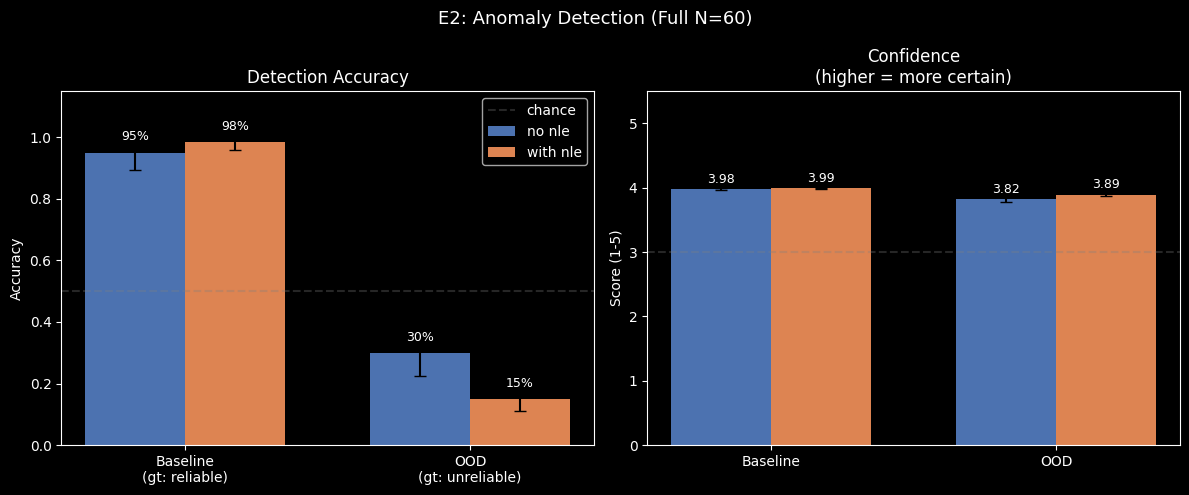

Figure saved: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E2/full_accuracy_by_condition.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_nle = {'no_nle': '#4C72B0', 'with_nle': '#DD8452'}
mode_label = 'Pilot N=15' if PILOT_MODE else 'Full N=60'

# Left panel: Accuracy by poisoning × NLE
ax = axes[0]
acc_data = df_valid.groupby(['poisoning', 'has_nle'])['correct'].agg(['mean', 'sum', 'count'])
x = np.arange(2)  # baseline, ood
width = 0.35

for i, (nle_label, nle_val) in enumerate([(False, 'no_nle'), (True, 'with_nle')]):
    vals = []
    errs_lo = []
    errs_hi = []
    for pois in ['baseline', 'ood']:
        if (pois, nle_label) in acc_data.index:
            row = acc_data.loc[(pois, nle_label)]
            a = row['mean']
            lo, hi = wilson_ci(int(row['sum']), int(row['count']))
            vals.append(a)
            errs_lo.append(a - lo)
            errs_hi.append(hi - a)
        else:
            vals.append(0)
            errs_lo.append(0)
            errs_hi.append(0)

    bars = ax.bar(x + i * width, vals, width,
                  yerr=[errs_lo, errs_hi], capsize=4,
                  label=nle_val.replace('_', ' '), color=colors_nle[nle_val])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{v:.0%}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(['Baseline\n(gt: reliable)', 'OOD\n(gt: unreliable)'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.set_title('Detection Accuracy')
ax.axhline(0.5, ls='--', color='gray', alpha=0.3, label='chance')
ax.legend()

# Right panel: Confidence by poisoning × NLE
ax2 = axes[1]
conf_valid = df_valid.dropna(subset=['confidence'])
if len(conf_valid) > 0:
    means = conf_valid.groupby(['poisoning', 'has_nle'])['confidence'].agg(['mean', 'sem'])
    for i, (nle_label, nle_val) in enumerate([(False, 'no_nle'), (True, 'with_nle')]):
        vals = []
        errs = []
        for pois in ['baseline', 'ood']:
            if (pois, nle_label) in means.index:
                vals.append(means.loc[(pois, nle_label), 'mean'])
                errs.append(means.loc[(pois, nle_label), 'sem'])
            else:
                vals.append(0)
                errs.append(0)
        bars = ax2.bar(x + i * width, vals, width, yerr=errs, capsize=4,
                       label=nle_val.replace('_', ' '), color=colors_nle[nle_val])
        for bar, v in zip(bars, vals):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f'{v:.2f}', ha='center', va='bottom', fontsize=9)

    ax2.set_xticks(x + width / 2)
    ax2.set_xticklabels(['Baseline', 'OOD'])
    ax2.set_ylim(0, 5.5)
    ax2.set_ylabel('Score (1-5)')
    ax2.set_title('Confidence\n(higher = more certain)')
    ax2.axhline(3, ls='--', color='gray', alpha=0.3)

fig.suptitle(f'E2: Anomaly Detection ({mode_label})', fontsize=13)
plt.tight_layout()

fig_path = RESULTS_DIR / f'{"pilot" if PILOT_MODE else "full"}_accuracy_by_condition.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print(f'Figure saved: {fig_path}')

## 9. Summary

In [11]:
# Save summary table
summary = df_valid.groupby(['poisoning', 'has_nle']).agg(
    accuracy=('correct', 'mean'),
    n_correct=('correct', 'sum'),
    n_total=('correct', 'count'),
    mean_confidence=('confidence', 'mean'),
).round(3)
summary.to_csv(RESULTS_DIR / f'{"pilot" if PILOT_MODE else "full"}_summary.csv')

print('=== E2 Summary ===')
print(summary)

# Key finding
print('\n=== Key finding ===')
ood_no_acc = df_valid[(df_valid['poisoning'] == 'ood') & (~df_valid['has_nle'])]['correct'].mean()
ood_yes_acc = df_valid[(df_valid['poisoning'] == 'ood') & (df_valid['has_nle'])]['correct'].mean()
base_no_acc = df_valid[(df_valid['poisoning'] == 'baseline') & (~df_valid['has_nle'])]['correct'].mean()
base_yes_acc = df_valid[(df_valid['poisoning'] == 'baseline') & (df_valid['has_nle'])]['correct'].mean()

print(f'DETECTION ACCURACY:')
print(f'  Baseline: no_nle={base_no_acc:.1%}, with_nle={base_yes_acc:.1%}, NLE effect={base_yes_acc-base_no_acc:+.1%}')
print(f'  OOD:      no_nle={ood_no_acc:.1%}, with_nle={ood_yes_acc:.1%}, NLE effect={ood_yes_acc-ood_no_acc:+.1%}')

# False reassurance
ood_fn_no = (df_valid[(df_valid['poisoning'] == 'ood') & (~df_valid['has_nle'])]['reliability'] == 'reliable').mean()
ood_fn_yes = (df_valid[(df_valid['poisoning'] == 'ood') & (df_valid['has_nle'])]['reliability'] == 'reliable').mean()
print(f'\nFALSE REASSURANCE (OOD called "reliable"):')
print(f'  No NLE:   {ood_fn_no:.1%}')
print(f'  With NLE: {ood_fn_yes:.1%}')

if ood_fn_yes > ood_fn_no:
    print(f'\n  -> False reassurance: NLE increases false negative rate for OOD instances')
    print(f'     This extends the Quality-Usefulness Gap to adversarial settings.')
elif ood_fn_yes < ood_fn_no:
    print(f'\n  -> NLE helps detect OOD instances (reduces false negatives)')
else:
    print(f'\n  -> No NLE effect on OOD false negative rate')

print()
if PILOT_MODE:
    print('NEXT: Review pilot results. If effect size is sufficient, set PILOT_MODE = False and re-run.')
else:
    print('Full experiment complete.')
    print(f'Results: {CACHE_PATH}')
    print(f'Summary: {RESULTS_DIR / "full_summary.csv"}')

=== E2 Summary ===
                   accuracy  n_correct  n_total  mean_confidence
poisoning has_nle                                               
baseline  False       0.950        114      120            3.983
          True        0.983        236      240            3.988
ood       False       0.300         36      120            3.817
          True        0.150         36      240            3.892

=== Key finding ===
DETECTION ACCURACY:
  Baseline: no_nle=95.0%, with_nle=98.3%, NLE effect=+3.3%
  OOD:      no_nle=30.0%, with_nle=15.0%, NLE effect=-15.0%

FALSE REASSURANCE (OOD called "reliable"):
  No NLE:   70.0%
  With NLE: 85.0%

  -> False reassurance: NLE increases false negative rate for OOD instances
     This extends the Quality-Usefulness Gap to adversarial settings.

Full experiment complete.
Results: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E2/full_results.csv
Summary: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E2/fu